In [1]:
# Laptop Price Prediction - Regression

## Objective
#To predict laptop prices using multiple machine learning regression algorithms and compare their performance.

#Workflow
#1. Dataset Loading
#2. Data Audit
#3. Exploratory Data Analysis
#4. Data Cleaning
#5. Feature Engineering
#6. Train-Test Split
#7. Preprocessing
#8. Model Training
#9. Model Comparison
#10. Hyperparameter Tuning
#11. Cross Validation
#12. Final Model Evaluation
#13. Feature Importance

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [6]:
#Load Dataset
df = pd.read_csv("regression.csv")

df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [7]:
#DataSet Audit
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1303, 12)

Column Names:
['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']

Data Types:
Unnamed: 0            int64
Company                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                     str
Memory                  str
Gpu                     str
OpSys                   str
Weight                  str
Price               float64
dtype: object

Missing Values:
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

Duplicate Rows:
0


In [8]:
#Unwanted index column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [9]:
#satistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company,1303,19,Dell,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,1303,6,Notebook,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,1303.0,NaN,NaN,NaN,15.017191,1.426304,10.1,14.0,15.6,15.6,18.4
ScreenResolution,1303,40,Full HD 1920x1080,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,1303,118,Intel Core i5 7200U 2.5GHz,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,1303,9,8GB,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,1303,39,256GB SSD,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,1303,110,Intel HD Graphics 620,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OpSys,1303,9,Windows 10,1072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,1303,179,2.2kg,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


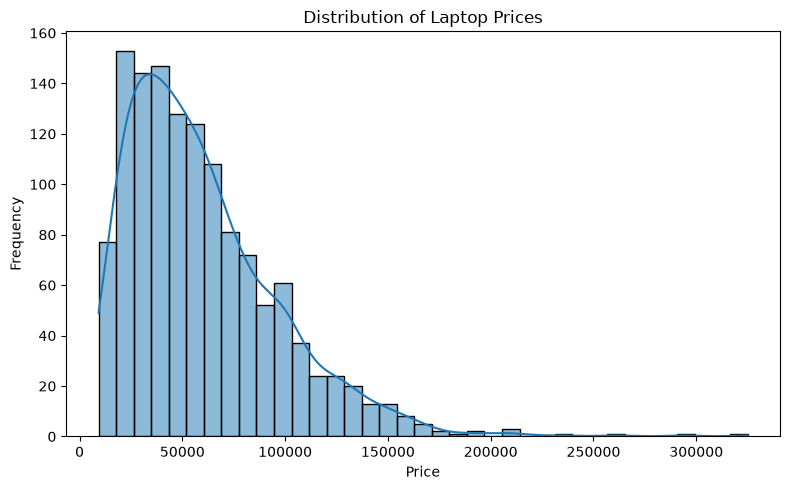

In [11]:
#Target Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Price"],
    kde=True
)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
# Observation

#The target distribution shows how laptop prices are distributed in the dataset. 
#We examine whether the target is approximately symmetric or skewed and identify 
#whether extreme price values may exist.

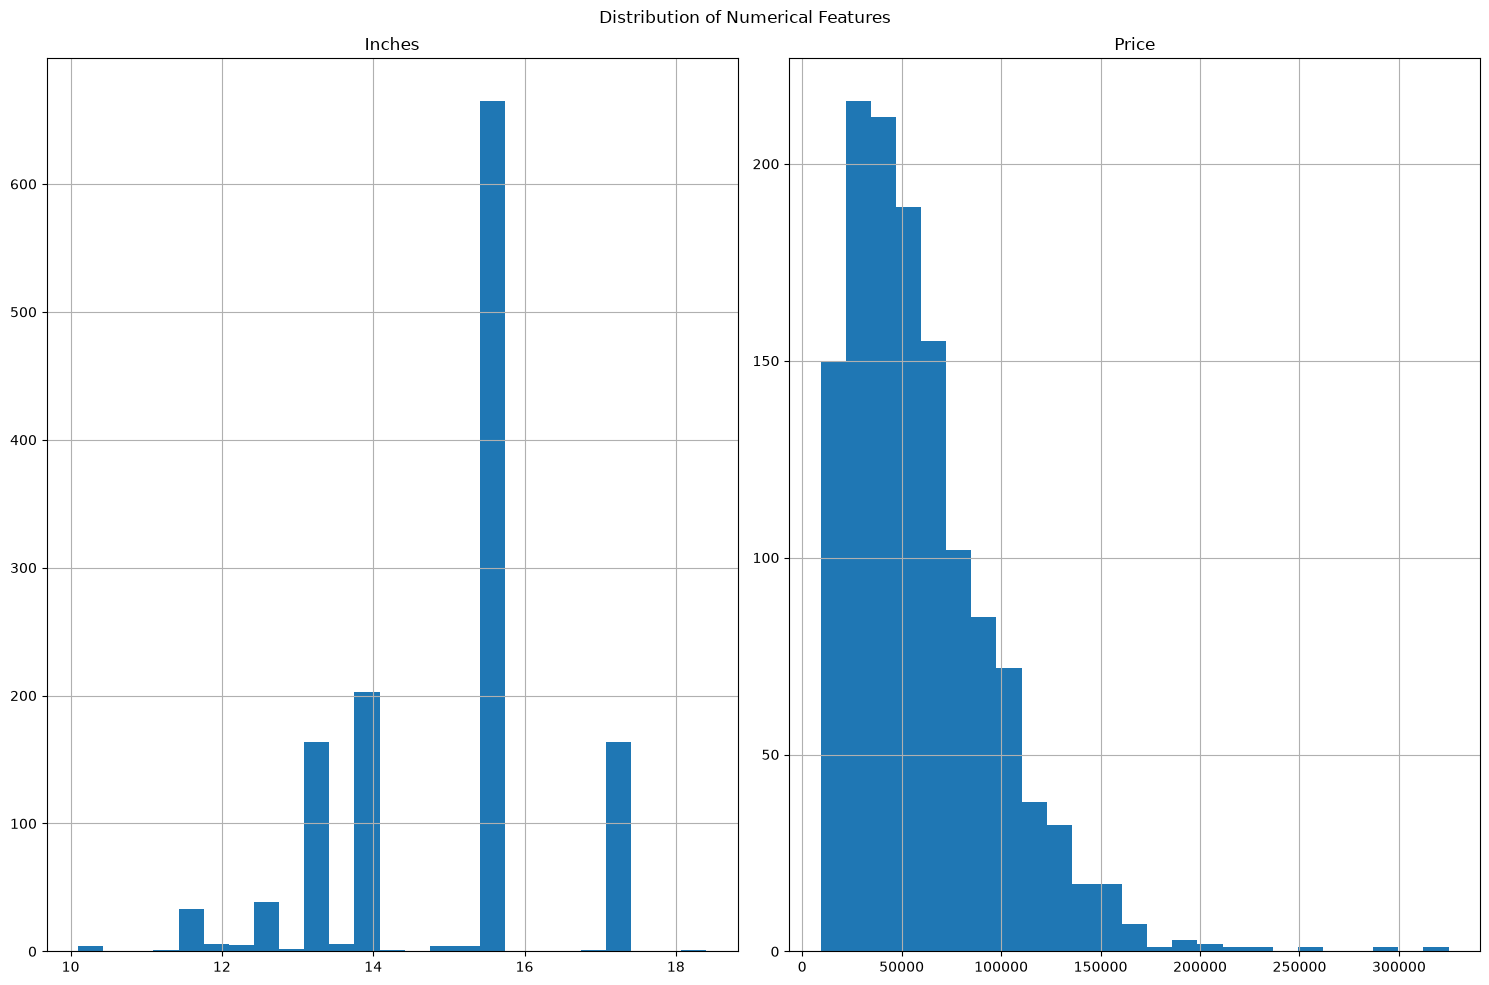

In [14]:
#Numerical Feature Distribution
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols].hist(
    figsize=(15, 10),
    bins=25
)

plt.suptitle(
    "Distribution of Numerical Features"
)

plt.tight_layout()
plt.show()

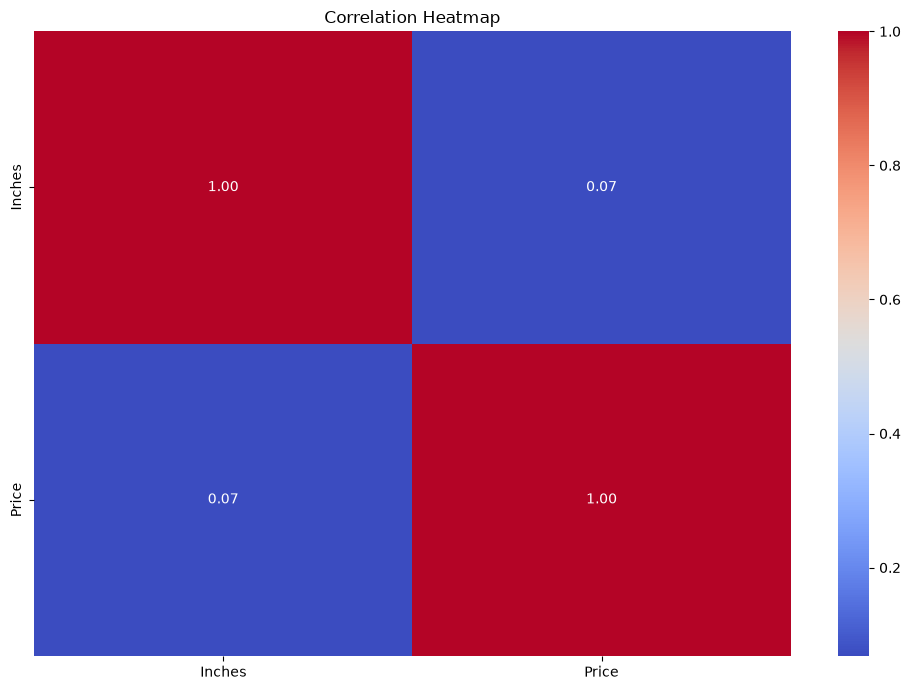

In [15]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [20]:
# Convert RAM to numeric
df["Ram"] = pd.to_numeric(df["Ram"], errors="coerce")

# Convert Weight to numeric
df["Weight"] = pd.to_numeric(
    df["Weight"].astype(str).str.replace("kg", "", regex=False),
    errors="coerce"
)

print(df[["Ram", "Weight"]].dtypes)
print(df[["Ram", "Weight"]].head())

Ram       float64
Weight    float64
dtype: object
    Ram  Weight
0   8.0    1.37
1   8.0    1.34
2   8.0    1.86
3  16.0    1.83
4   8.0    1.37


In [22]:
#Feature Engineering
df["Touchscreen"] = (
    df["ScreenResolution"]
    .str.contains("Touchscreen", case=False, regex=False)
    .astype(int)
)

df["IPS"] = (
    df["ScreenResolution"]
    .str.contains("IPS", case=False, regex=False)
    .astype(int)
)

resolution = df["ScreenResolution"].str.extract(
    r"(\d+)x(\d+)"
)

df["ScreenWidth"] = resolution[0].astype(float)
df["ScreenHeight"] = resolution[1].astype(float)

df["PixelCount"] = (
    df["ScreenWidth"] *
    df["ScreenHeight"]
)

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ScreenWidth,ScreenHeight,PixelCount
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560.0,1600.0,4096000.0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440.0,900.0,1296000.0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920.0,1080.0,2073600.0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880.0,1800.0,5184000.0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560.0,1600.0,4096000.0


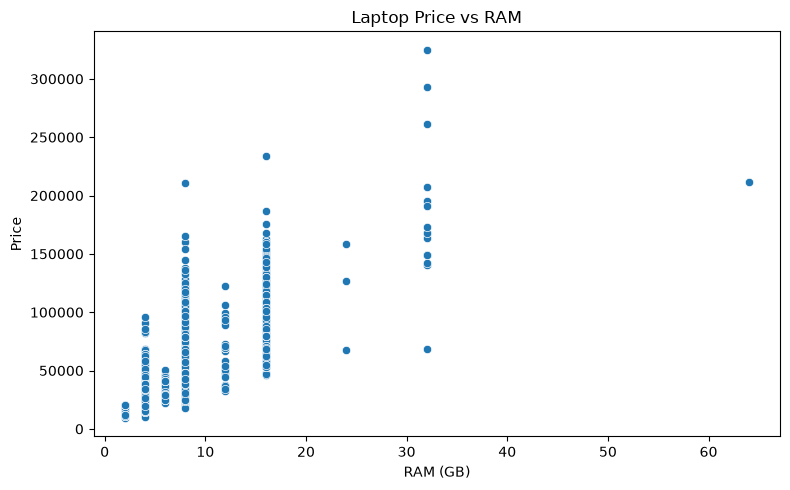

In [23]:
#scatter plot 1
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Ram",
    y="Price"
)

plt.title("Laptop Price vs RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

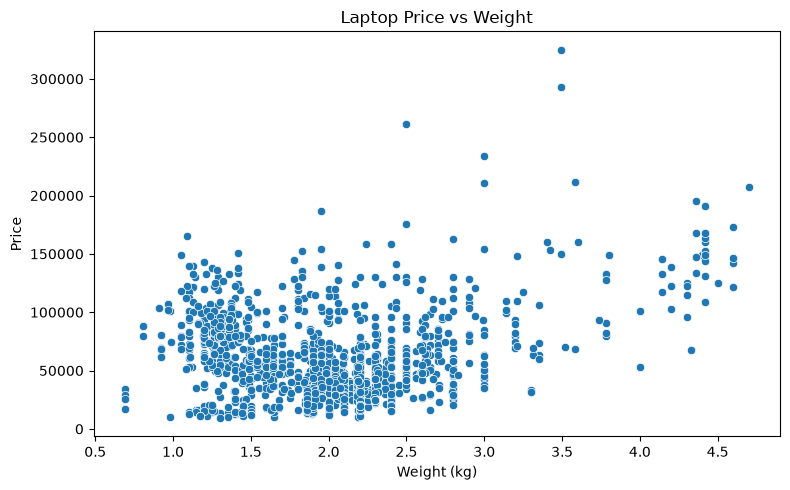

In [24]:
#scatter plot 2
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Weight",
    y="Price"
)

plt.title("Laptop Price vs Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

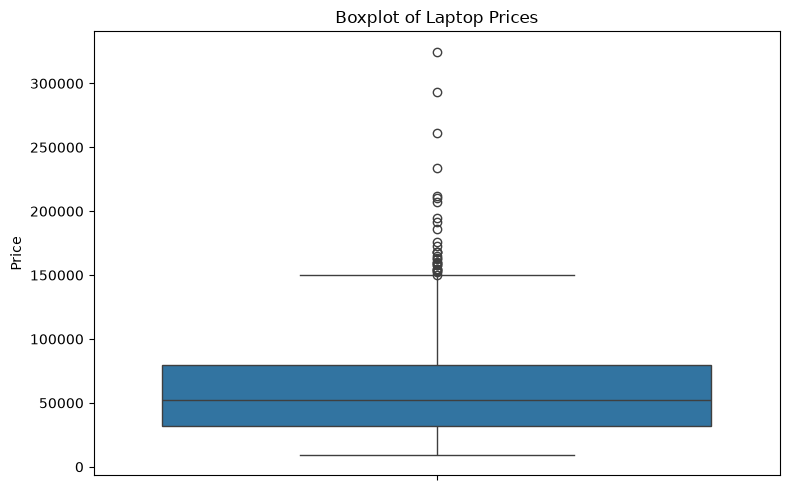

In [25]:
#check outliers
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["Price"]
)

plt.title("Boxplot of Laptop Prices")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [26]:
print(df["Price"].describe())

count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%       31914.720000
50%       52054.560000
75%       79274.246400
max      324954.720000
Name: Price, dtype: float64


In [27]:
#prepare X and Y
X = df.drop(
    columns=["Price"]
)

y = df["Price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1303, 15)
y Shape: (1303,)


In [28]:
#identify columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Inches', 'Ram', 'Weight', 'Touchscreen', 'IPS', 'ScreenWidth', 'ScreenHeight', 'PixelCount']

Categorical Features:
['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys']


In [29]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1042, 15)
Testing data: (261, 15)


In [31]:
#preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [32]:
#Defining all 10
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(alpha=1.0),

    "Lasso":
        Lasso(
            alpha=0.001,
            max_iter=10000
        ),

    "ElasticNet":
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=10000
        ),

    "Polynomial Regression":
        Pipeline([
            (
                "poly",
                PolynomialFeatures(
                    degree=2,
                    include_bias=False
                )
            ),
            (
                "linear",
                LinearRegression()
            )
        ]),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "SVR":
        SVR(
            kernel="rbf"
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=5
        )
}

In [33]:
#Train all 10
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = pipeline

In [34]:
#required comparison table
regression_results = pd.DataFrame(
    results
)

regression_results = (
    regression_results
    .sort_values(
        by="R2",
        ascending=False
    )
    .reset_index(drop=True)
)

regression_results

,Model,R2,RMSE,MAE
0,ElasticNet,0.860280,14193.646140,9991.016401
1,Ridge,0.856603,14379.184603,10029.935570
2,Linear Regression,0.842479,15070.715904,10630.586522
3,Gradient Boosting,0.840292,15174.972155,10425.520223
4,Lasso,0.838475,15261.031387,10807.484532
5,Random Forest,0.796333,17136.616735,10346.586120
6,Decision Tree,0.748120,19057.302665,12103.039890
7,KNN,0.735724,19520.601475,12263.363697
8,SVR,-0.028161,38503.057298,26385.322616
9,Polynomial Regression,-8.424118,116569.522920,56227.624753


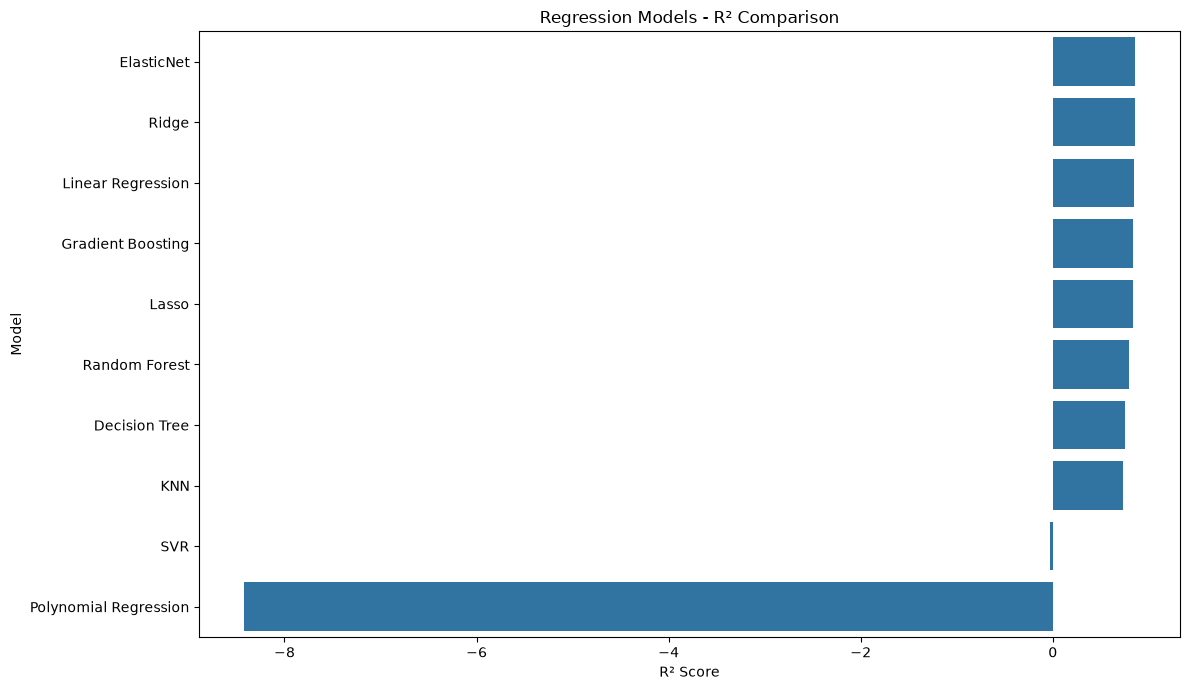

In [35]:
#R2 Comparison
plt.figure(figsize=(12, 7))

sns.barplot(
    data=regression_results,
    x="R2",
    y="Model"
)

plt.title("Regression Models - R² Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

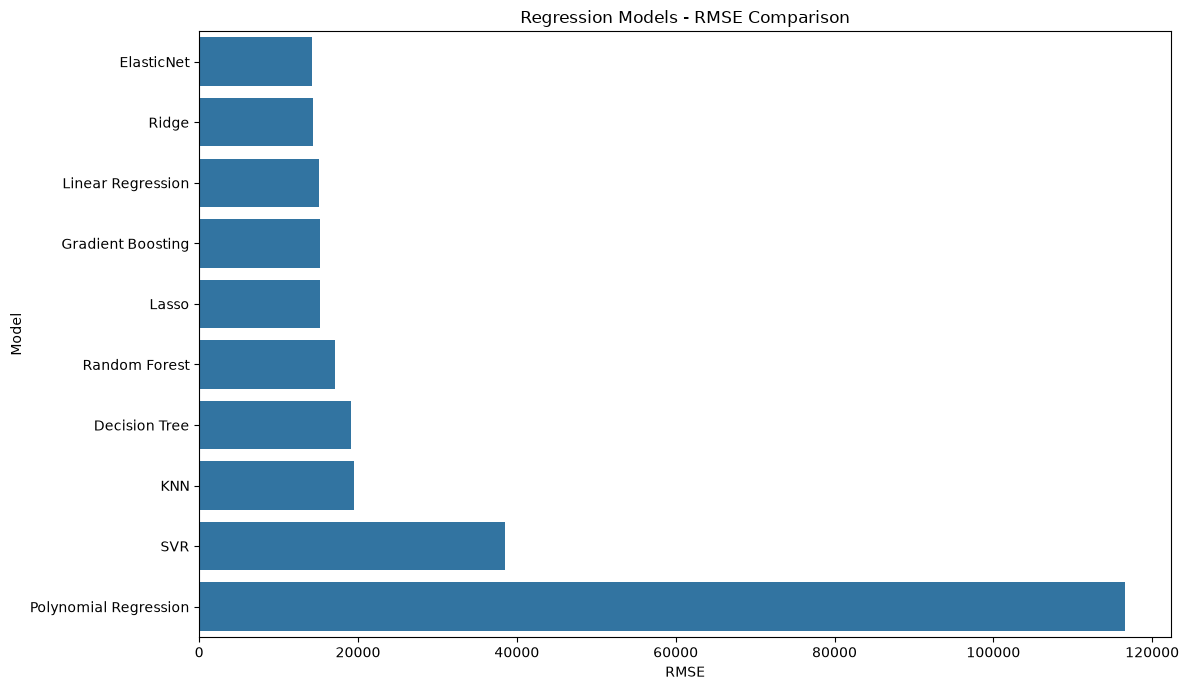

In [38]:
#RMSE comparison
plt.figure(figsize=(12, 7))

sns.barplot(
    data=regression_results,
    x="RMSE",
    y="Model"
)

plt.title("Regression Models - RMSE Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

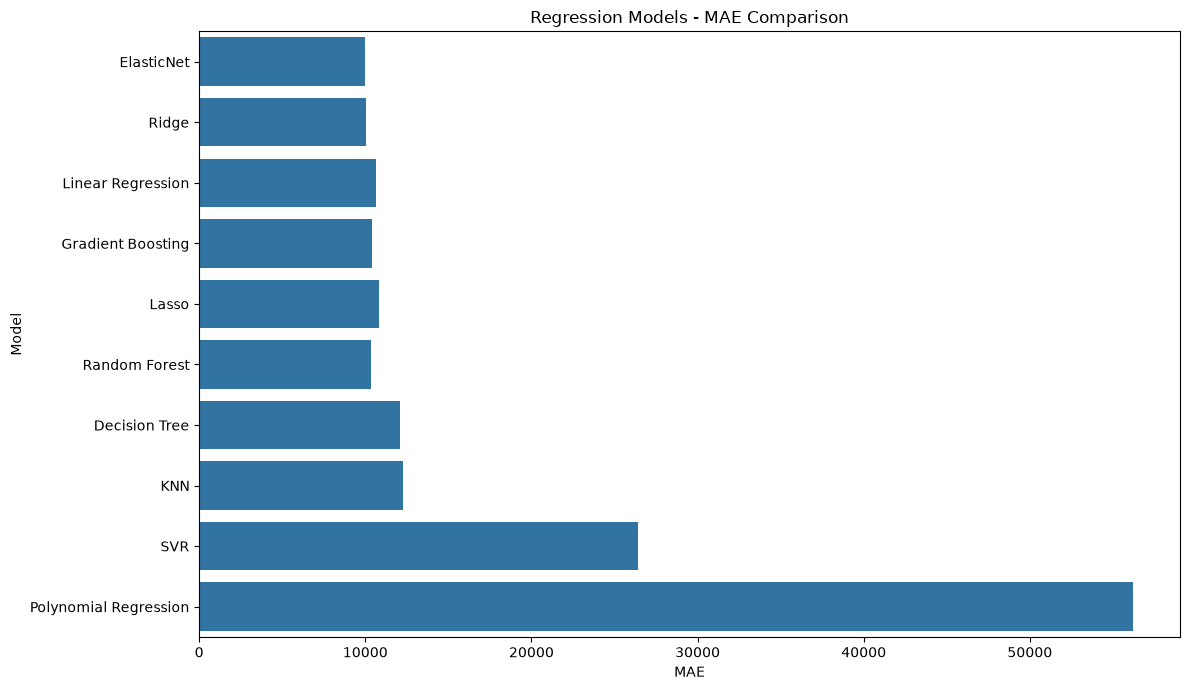

In [39]:
#MAE Comparison
plt.figure(figsize=(12, 7))

sns.barplot(
    data=regression_results,
    x="MAE",
    y="Model"
)

plt.title("Regression Models - MAE Comparison")
plt.xlabel("MAE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [40]:
#True Random Forest
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV R²:
0.8231896053051326


In [41]:
#Tune Gradient Boosting
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(gb_grid.best_params_)

print("\nBest CV R²:")
print(gb_grid.best_score_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}

Best CV R²:
0.8220846232592207


In [42]:
#5-Fold CV for two best models
cv_models = {
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

cv_results = []

for name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean R2": scores.mean(),
        "CV Std": scores.std()
    })

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df

,Model,CV Mean R2,CV Std
0,Random Forest,0.823190,0.041813
1,Gradient Boosting,0.822085,0.038025


In [44]:
# Hyperparameter tuning results

tuned_results = []

for name, model, params in [
    (
        "Random Forest Regressor",
        Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5]
        }
    ),
    (
        "Gradient Boosting Regressor",
        Pipeline([
            ("preprocessor", preprocessor),
            ("model", GradientBoostingRegressor(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    )
]:

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    tuned_results.append({
        "Model": name + " (Tuned)",
        "R2": r2_score(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, y_pred),
        "Best Parameters": grid.best_params_
    })

    print(name)
    print("Best Parameters:", grid.best_params_)
    print("Test R2:", r2_score(y_test, y_pred))
    print()
    
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

Random Forest Regressor
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Test R2: 0.791845901546328

Gradient Boosting Regressor
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Test R2: 0.8582805840317759



,Model,R2,RMSE,MAE,Best Parameters
0,Random Forest Regressor (Tuned),0.791846,17324.357848,10403.062375,"{'model__max_depth': None, 'model__min_samples..."
1,Gradient Boosting Regressor (Tuned),0.858281,14294.841346,9654.444687,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [45]:
#choose final best model
comparison_final = pd.concat(
    [
        regression_results,
        tuned_results_df
    ],
    ignore_index=True
)

comparison_final.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,RMSE,MAE,Best Parameters
0,ElasticNet,0.860280,14193.646140,9991.016401,NaN
11,Gradient Boosting Regressor (Tuned),0.858281,14294.841346,9654.444687,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,Ridge,0.856603,14379.184603,10029.935570,NaN
2,Linear Regression,0.842479,15070.715904,10630.586522,NaN
3,Gradient Boosting,0.840292,15174.972155,10425.520223,NaN
4,Lasso,0.838475,15261.031387,10807.484532,NaN
5,Random Forest,0.796333,17136.616735,10346.586120,NaN
10,Random Forest Regressor (Tuned),0.791846,17324.357848,10403.062375,"{'model__max_depth': None, 'model__min_samples..."
6,Decision Tree,0.748120,19057.302665,12103.039890,NaN
7,KNN,0.735724,19520.601475,12263.363697,NaN


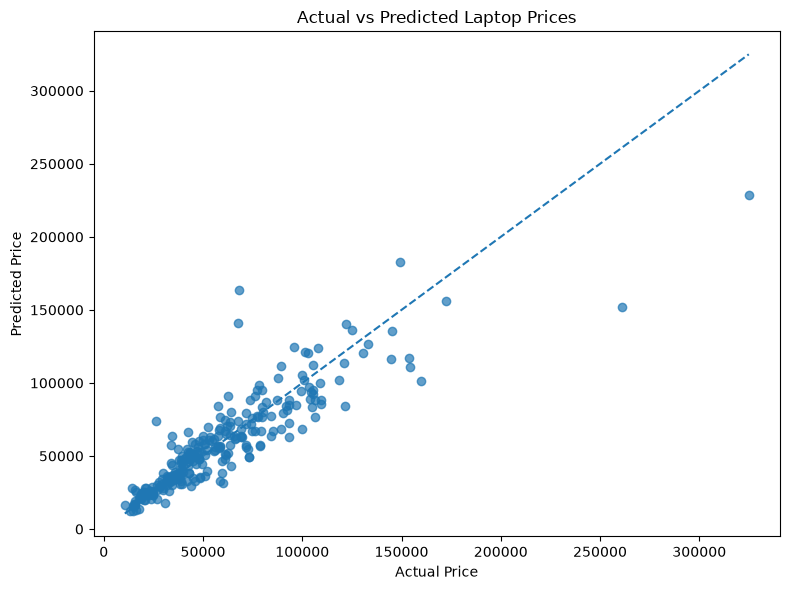

In [47]:
#Actual vs Predicted
best_model = rf_grid.best_estimator_

y_pred_best = best_model.predict(
    X_test
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Laptop Prices"
)

plt.tight_layout()
plt.show()